<a href="https://colab.research.google.com/github/552radhika-Dev/Final_Capstoneproj_Radhika/blob/main/part1/Capstone_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1 — Data Acquisition, Cleaning, and Exploratory Analysis**

In [78]:
import pandas as pd
#Reading the dataset
df=pd.read_csv("https://raw.githubusercontent.com/552radhika-Dev/Final_Capstoneproj_Radhika/main/part1/Cardetails_dataset.csv")
#Printing data shape and data types
print(df.shape)
print(df.dtypes)
print(df.head(5))

(8128, 13)
name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner     mileage   engine   max_power  \
0  Individual       Manual   First Owner   23.4 kmpl  1248 CC      74 bhp   
1  Individual       Manual  Second Owner  21.

In [79]:
#Finding null count
null_count=df.isnull().sum()
print(f'Null Count:{null_count}')


Null Count:name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


In [80]:
#Finding null percentage
null_percentage=((df.isnull().sum()/df.shape[0])*100)
print(f'Null Percentage:{null_percentage}')


Null Percentage:name             0.000000
year             0.000000
selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          2.718996
engine           2.718996
max_power        2.645177
torque           2.731299
seats            2.718996
dtype: float64


In [81]:
#Finding columns which has null values greater than 20%
col_with_null_values=null_percentage[null_percentage>20]
if len(col_with_null_values) == 0:
    print('No columns have null values greater than 20%.')
else:
    print(f'Columns with null values greater than 20%:{col_with_null_values}')

No columns have null values greater than 20%.


In [82]:
#Converting datatypes of actual numeric columns from object to numeric type
df_clean=df.copy()
df_clean['mileage']=pd.to_numeric(df_clean['mileage'].str.replace(' kmpl','', regex=False), errors='coerce')
df_clean['engine']=pd.to_numeric(df_clean['engine'].str.replace(' CC','', regex=False), errors='coerce')
df_clean['max_power']=pd.to_numeric(df_clean['max_power'].str.replace(' bhp','', regex=False), errors='coerce')
print(df_clean.dtypes)

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
torque            object
seats            float64
dtype: object


In [83]:
#displaying labels of all numeric columns
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
# print(numeric_columns)
#Filling numeric cols with null percentage below 20 using median
for col in numeric_columns:
  null_percentage = (df_clean[col].isnull().sum() / df_clean.shape[0]) * 100
  if (null_percentage> 0) and (null_percentage < 20):
    col_median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(col_median)
    print(f"Filled column '{col}' with its median value: {col_median}")

Filled column 'mileage' with its median value: 19.3
Filled column 'engine' with its median value: 1248.0
Filled column 'max_power' with its median value: 82.0
Filled column 'seats' with its median value: 5.0


In [84]:
#Finding duplicates and removing it
total_rows = df_clean.shape[0]
print(f"Total rows in the DataFrame: {total_rows}")
duplicates_count=df_clean.duplicated().sum()
print(f"Total duplicate rows in the DataFrame: {duplicates_count}")
df_clean=df_clean.drop_duplicates()
print(f"Total rows after dropping duplicates: {df_clean.shape[0]}")
print(f'Initial Null Percentage:{null_percentage}')
null_percentage_df_clean = (df_clean[col].isnull().sum() / df_clean.shape[0]) * 100
print(f'Null Percentage after dropping duplicates:{null_percentage_df_clean}')
df_clean.shape

Total rows in the DataFrame: 8128
Total duplicate rows in the DataFrame: 1202
Total rows after dropping duplicates: 6926
Initial Null Percentage:2.718996062992126
Null Percentage after dropping duplicates:0.0


(6926, 13)

In [85]:
#Dropping torque column since its messy and not required for future purpose
df_clean=df_clean.drop(columns=['torque'])

In [86]:
print(f'Original df:\n{df.isnull().sum()}\n')
print(f'Cleaned df:\n{df_clean.isnull().sum()}')

Original df:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Cleaned df:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64


In [87]:
#Memory usage before conversion of repetitive string columns to category
memory_before = df_clean.memory_usage(deep=True).sum()
print(f'Memory usage before conversion: {memory_before} bytes')
#Convert repetitive string columns to 'category' data type
categorical_cols = ['fuel', 'transmission', 'owner']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')
#Memory usage after conversion of repetitive string columns to category
memory_after=df_clean.memory_usage(deep=True).sum()
print(f'Memory usage after conversion: {memory_after} bytes')

Memory usage before conversion: 2545136 bytes
Memory usage after conversion: 1384606 bytes


In [88]:
#displaying statistics
df_clean.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.428806,1425.398787,87.556583,5.421600
std,4.078286,5.197670e+05,5.835810e+04,3.925169,487.026967,31.310612,0.972171
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,17.000000,1197.000000,68.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.300000,1248.000000,81.860000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.300000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [89]:
#Finding highest skewed column in df_clean
core_cols = ['selling_price', 'km_driven', 'mileage', 'engine', 'max_power']
skew_values={}
for col in core_cols:
  skewness=df_clean[col].skew()
  skew_values[col]=skewness
  print(f"Skewness of '{col}': {skewness}")
highest_skew_col=max(skew_values)
print(f'Highest Skewed Column:{highest_skew_col}')

Skewness of 'selling_price': 5.572742292649192
Skewness of 'km_driven': 11.758425539599084
Skewness of 'mileage': -0.19730160888266463
Skewness of 'engine': 1.2589510852257322
Skewness of 'max_power': 1.7367136220908928
Highest Skewed Column:selling_price


In [90]:
#Detecting outliers
target_cols = ['selling_price', 'km_driven']
for col in target_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR
  outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
  outlier_count = len(outliers)
  print(f"\nColumn: '{col}'")
  print(f"Q1 (25th percentile): {Q1:,.2f}")
  print(f"Q3 (75th percentile): {Q3:,.2f}")
  print(f"IQR: {IQR:,.2f}")
  print(f"Lower Bound: {lower_bound:,.2f}")
  print(f"Upper Bound: {upper_bound:,.2f}")
  print(f"Number of Outliers Detected: {outlier_count} rows")



Column: 'selling_price'
Q1 (25th percentile): 254,999.00
Q3 (75th percentile): 675,000.00
IQR: 420,001.00
Lower Bound: -375,002.50
Upper Bound: 1,305,001.50
Number of Outliers Detected: 284 rows

Column: 'km_driven'
Q1 (25th percentile): 35,000.00
Q3 (75th percentile): 98,000.00
IQR: 63,000.00
Lower Bound: -59,500.00
Upper Bound: 192,500.00
Number of Outliers Detected: 165 rows


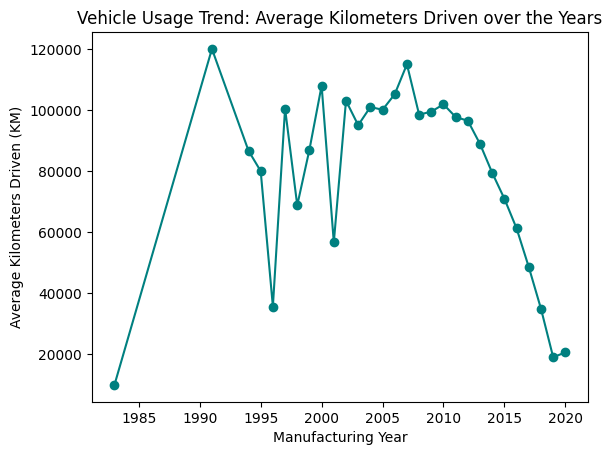

In [91]:
#Creating a line plot
import matplotlib.pyplot as plt
#Grouping the data by 'year' and calculate the average kilometers driven instantly
timeline_data = df_clean.groupby('year')['km_driven'].mean()
plt.plot(timeline_data.index, timeline_data.values, marker='o', color='teal')
#Add clear titles and labels
plt.title('Vehicle Usage Trend: Average Kilometers Driven over the Years')
plt.xlabel('Manufacturing Year')
plt.ylabel('Average Kilometers Driven (KM)')
plt.show()

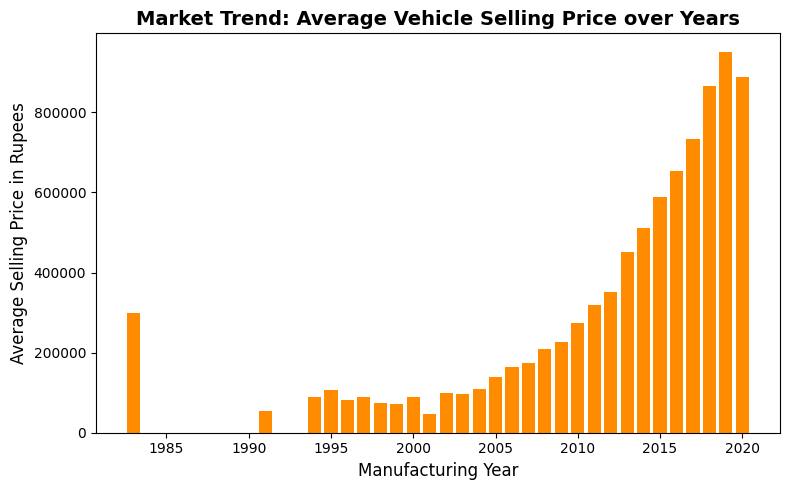

In [92]:
#Creating the bar plot
import matplotlib.pyplot as plt
#Grouping the data by 'year' and calculate the mean selling price for each year
yearly_trends = df_clean.groupby('year')['selling_price'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(yearly_trends['year'], yearly_trends['selling_price'],color='darkorange', linewidth=2.5)
#Add required titles and labels
plt.title('Market Trend: Average Vehicle Selling Price over Years', fontsize=14, fontweight='bold')
plt.xlabel('Manufacturing Year', fontsize=12)
plt.ylabel('Average Selling Price in Rupees', fontsize=12)
plt.tight_layout()
plt.show()

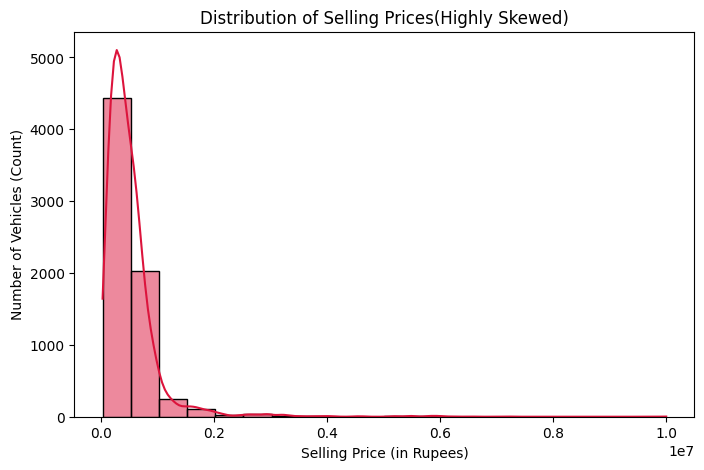

In [93]:
#Creating histogram
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['selling_price'], bins=20, color='crimson', kde=True)
#Add required title and labels
plt.title('Distribution of Selling Prices(Highly Skewed)')
plt.xlabel('Selling Price (in Rupees)')
plt.ylabel('Number of Vehicles (Count)')
plt.show()

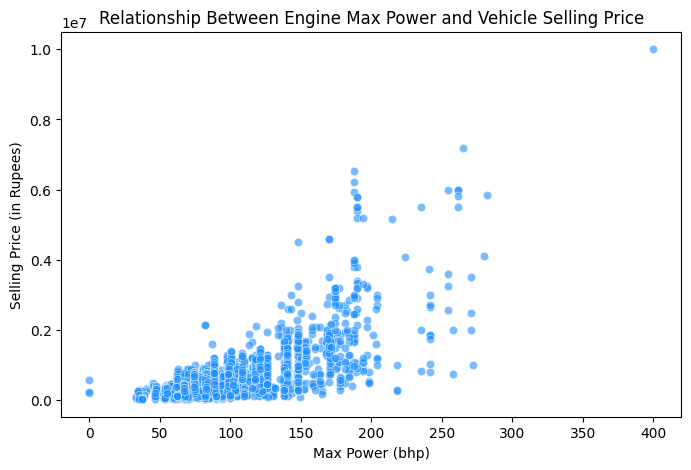

In [94]:
#Creating Scatter plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='max_power', y='selling_price', color='dodgerblue', alpha=0.6)
#Add clear, required titles and labels
plt.title('Relationship Between Engine Max Power and Vehicle Selling Price')
plt.xlabel('Max Power (bhp)')
plt.ylabel('Selling Price (in Rupees)')
plt.show()

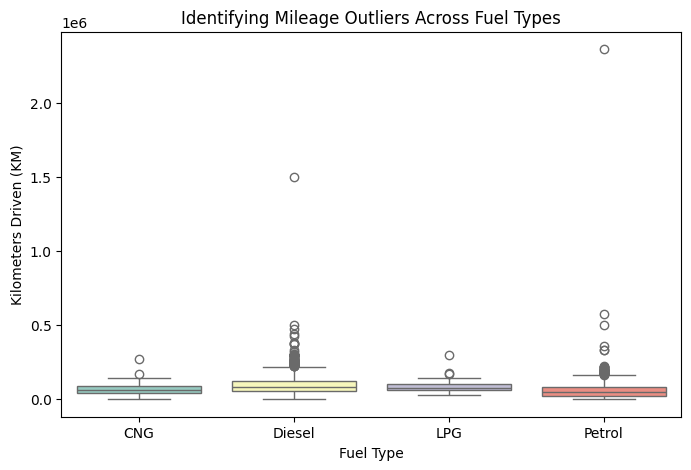

In [95]:
#Creating box plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x='fuel',
    y='km_driven',
    hue='fuel',
    legend=False,
    palette='Set3',
    width=0.8
)
#Add clear titles and labels required by your assignment
plt.title('Identifying Mileage Outliers Across Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Kilometers Driven (KM)')
plt.show()

Box Plot Distribution Analysis

- **Visible Differences in Median and Spread Across Categories:**
  - **Difference in Medians:** The median line inside the **Diesel** box sits visibly higher up the scale than the **Petrol** box. This confirms the market reality that diesel vehicles are systematically purchased for heavier, longer-distance usage.
  - **Difference in Spread and Outliers:** The **Diesel** box exhibits a taller vertical spread, indicating a wider variation in standard usage habits. Crucially, both categories display clear **individual outlier points** extending far above the upper whisker bound. These represent commercial cars with extreme mileage totals that deviate from typical consumer driving habits, showing exactly why the IQR method flagged them as statistical outliers.

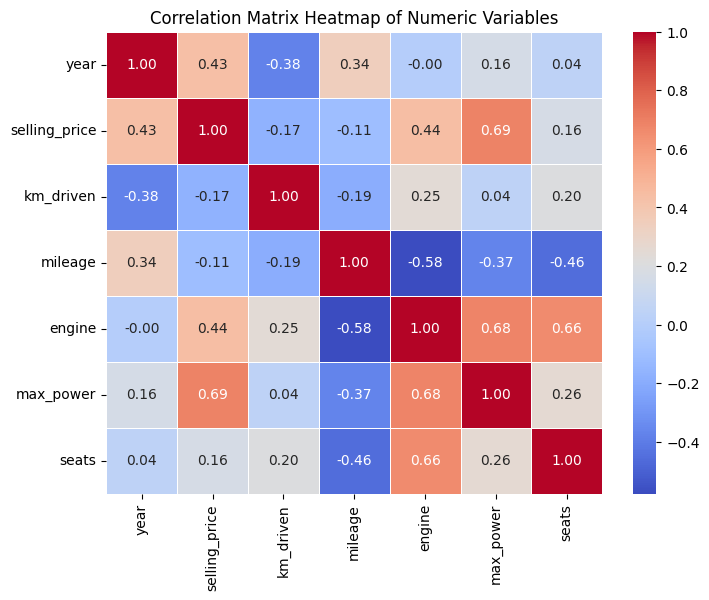

In [96]:
#Heatmp
import matplotlib.pyplot as plt
import seaborn as sns
#Selecting only the numeric columns to avoid any errors/warnings
numeric_df = df_clean.select_dtypes(include=['number'])
#Computing the correlation matrix
corr_matrix = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap of Numeric Variables')
plt.show()

In [97]:
#Immputing strategy comparison
#Identify the two columns
skewed_cols = ['selling_price', 'km_driven']
for col in skewed_cols:
    col_mean = df_clean[col].mean()
    col_median = df_clean[col].median()
    print(f"Column: {col}")
    print(f"Mean  : {col_mean:.2f}")
    print(f"Median: {col_median:.2f}\n")
#Imputing missing values with the Median (since both are highly right-skewed)
for col in skewed_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)
print(df_clean[skewed_cols].isnull().sum())

Column: selling_price
Mean  : 517270.68
Median: 400000.00

Column: km_driven
Mean  : 73995.68
Median: 70000.00

selling_price    0
km_driven        0
dtype: int64


In [98]:
#Spearman / Pearson Coefficients
import pandas as pd
import numpy as np

# 1. Isolate numeric columns
numeric_df = df_clean.select_dtypes(include=['number'])

# 2. Compute both correlation matrices
pearson_matrix = numeric_df.corr(method='pearson')
spearman_matrix = numeric_df.corr(method='spearman')

print("--- PEARSON CORRELATION MATRIX ---")
print(pearson_matrix.round(4))
print("\n--- SPEARMAN RANK CORRELATION MATRIX ---")
print(spearman_matrix.round(4))

# 3. Calculate absolute differences between the two matrices
diff_matrix = (spearman_matrix - pearson_matrix).abs()

# 4. Extract unique pairs (ignoring diagonal and duplicate matrix mirrors)
pairs = []
columns = numeric_df.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col1, col2 = columns[i], columns[j]
        p_val = pearson_matrix.loc[col1, col2]
        s_val = spearman_matrix.loc[col1, col2]
        abs_diff = diff_matrix.loc[col1, col2]
        pairs.append({
            'Pair': f"{col1} & {col2}",
            'Pearson': p_val,
            'Spearman': s_val,
            '|Spearman - Pearson|': abs_diff
        })

# 5. Convert to dataframe and sort to find the top 3 highest differences
diff_df = pd.DataFrame(pairs).sort_values(by='|Spearman - Pearson|', ascending=False)

print("\n--- TOP 3 COLUMN PAIRS WITH LARGEST DIFFERENCE ---")
print(diff_df.head(3).to_string(index=False))

--- PEARSON CORRELATION MATRIX ---
                 year  selling_price  km_driven  mileage  engine  max_power  \
year           1.0000         0.4331    -0.3770   0.3438 -0.0011     0.1585   
selling_price  0.4331         1.0000    -0.1656  -0.1063  0.4448     0.6888   
km_driven     -0.3770        -0.1656     1.0000  -0.1947  0.2467     0.0395   
mileage        0.3438        -0.1063    -0.1947   1.0000 -0.5778    -0.3739   
engine        -0.0011         0.4448     0.2467  -0.5778  1.0000     0.6830   
max_power      0.1585         0.6888     0.0395  -0.3739  0.6830     1.0000   
seats          0.0423         0.1639     0.2010  -0.4593  0.6594     0.2604   

                seats  
year           0.0423  
selling_price  0.1639  
km_driven      0.2010  
mileage       -0.4593  
engine         0.6594  
max_power      0.2604  
seats          1.0000  

--- SPEARMAN RANK CORRELATION MATRIX ---
                 year  selling_price  km_driven  mileage  engine  max_power  \
year           1.00

In [99]:
#Computing grouped aggregation for transmission types on selling_price
grouped_summary = df_clean.groupby('transmission')['selling_price'].agg(['mean', 'std', 'count'])
print("--- GROUPED AGGREGATION RESULTS ---")
print(grouped_summary.to_string())
highest_mean = grouped_summary['mean'].max()
lowest_mean = grouped_summary['mean'].min()
mean_ratio = highest_mean / lowest_mean

print(f"Ratio of Highest Group Mean to Lowest Group Mean: {mean_ratio:.2f}")

--- GROUPED AGGREGATION RESULTS ---
                      mean           std  count
transmission                                   
Automatic     1.309712e+06  1.254625e+06    584
Manual        4.442991e+05  2.952205e+05   6342
Ratio of Highest Group Mean to Lowest Group Mean: 2.95


/tmp/ipykernel_9504/1063150831.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_summary = df_clean.groupby('transmission')['selling_price'].agg(['mean', 'std', 'count'])


In [100]:
#Saving the cleaned dataset
df_clean.to_csv('cleaned_data.csv', index=False)

print("✅ Cleaned dataset successfully saved as 'cleaned_data.csv'!")

✅ Cleaned dataset successfully saved as 'cleaned_data.csv'!
